# Предсказание вероятности клика 

**Описание исследования**  
  
В условиях высокой конкуренции на рынке цифровой рекламы эффективность размещения рекламных объявлений является ключевым фактором успеха рекламных платформ и рекламодателей. Для максимизации дохода и повышения качества пользовательского опыта особенно важно корректно оценивать вероятность клика пользователя по рекламному объявлению в конкретном контексте показа.  
  
В рамках проекта рассматривается задача бинарной классификации — прогнозирование факта клика пользователя по рекламному баннеру на основе характеристик рекламного слота, площадки, приложения, устройства пользователя и контекста показа. Данные были получены из логов рекламных аукционов. 
  
Основная идея исследования заключается в построении модели машинного обучения, способной на основе исторических данных оценивать вероятность клика по объявлению, что позволяет оптимизировать доход рекламной платформы.  
  
**Цель исследования**  
  
Целью исследования является построение модели машинного обучения, способной предсказывать вероятность клика пользователя по рекламному объявлению на основе набора категориальных и числовых признаков, а также оценка качества и калибровки полученных предсказаний.  
    
**Задачи исследования** 
  
1.	Загрузка и первичная обработка данных       
    • анализ структуры датасета          
    • удаление технических и неинформативных признаков.         
2.	Проведение исследовательского анализа данных (EDA), включающего:    
	•	анализ распределений числовых признаков и выявление выбросов  
	•	анализ категориальных признаков и их кардинальности    
	•	визуализацию признаков    
	•	анализ зависимости признаков от целевой переменной 
	•	исследование корреляций между признаками и выявление мультиколлинеарности.  
3.	Подготовка данных для обучения моделей  
	•	разделение данных на обучающую, калибровочную и тестовую выборки с сохранением баланса классов 
	•	разработка пайплайна предварительной обработки данных  
	•	кодирование категориальных признаков     
	•	масштабирование числовых признаков. 
4.	Построение и обучение моделей   
	•	построение базовой модели (DummyClassifier) для оценки качества бейзлайна  
	•	обучение моделей логистической регрессии и линейного SVC      
	•	подбор гиперпараметров моделей с использованием кросс-валидации     
	•	оценка качества моделей по метрике PR-AUC.  
5.	Анализ результатов и интерпретация моделей  
	•	сравнение качества моделей на кросс-валидации и тестовой выборке             
	•	выявление наиболее значимых признаков, влияющих на вероятность клика       
6.	Калибровка вероятностных предсказаний   
	•	оценка качества калибровки моделей  
	•	применение изотонической калибровки     
	•	сравнение моделей до и после калибровки с использованием метрик Brier score, ECE и MCE   
7.	Формирование итоговых выводов   
	•	оценка применимости модели для использования в рекламной платформе   
	•	анализ преимуществ и ограничений полученного решения       
	•	формулирование рекомендаций по дальнейшему улучшению модели.    

## 1. Подготовка среды и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik as ph
from phik import phik_matrix

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold, SequentialFeatureSelector
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay

import category_encoders as ce
import joblib

In [2]:
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv')

In [4]:
df.head() 

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [5]:
df.shape 

(50000, 34)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

данные успешно загржены.  
данные содержат 50000 строк и 34 поля. 

## 2. Исследовательский анализ данных (EDA)

### Базовая информация о датасете  

**Описание полей**  
   
Идентификаторы и временные метки:  
- id — уникальный идентификатор записи о показе баннера  
- hour — час, в который был показан баннер, в формате YYMMDDHH. 
  
Характеристики рекламной площадки ( Site ):
- site_id — идентификатор веб-сайта, на котором был показан баннер. 
- site_domain — домен веб-сайта. 
- site_category — тематическая категория веб-сайта.   
  
Характеристики рекламируемого приложения ( App ):  
- app_id — идентификатор рекламируемого мобильного приложения. 
- app_domain — домен рекламируемого приложения. 
- app_category — категория рекламируемого приложения.  
    
Характеристики устройства и соединения пользователя:
- device_id — идентификатор браузера или устройства;
- device_ip — IP-адрес устройства;
- device_model — модель устройства;
- device_type — тип устройства пользователя: например, смартфон, планшет, ПК;
- device_conn_type — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.
  
Характеристики рекламного баннера и аукциона:  
- C1 — анонимизированный признак, характеризующий контекст показа.  
- banner_pos — позиция баннера на веб-странице.  
- C14 — C21 — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.  
  
Машинно-сгенерированные признаки (ML Features):  
- ml_feature_1, ml_feature_3 — ml_feature_6, ml_feature_8 — ml_feature_10 — числовые признаки,   полученные в результате предварительной обработки и генерации новых признаков.  
- ml_feature_2, ml_feature_7 — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.  
  
Целевая переменная:
- click — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.


### Анализ целевой переменной

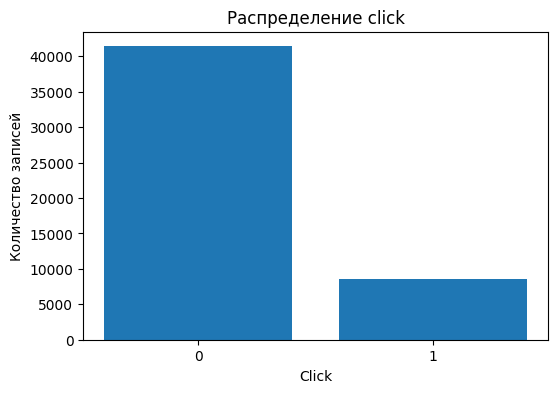

In [7]:
click_counts = df['click'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(click_counts.index.astype(str), click_counts.values)
plt.xlabel('Click')
plt.ylabel('Количество записей')
plt.title('Распределение click')
plt.show()

In [8]:
df['click'].value_counts(normalize=True)

click
0    0.82794
1    0.17206
Name: proportion, dtype: float64

таргет распределен неравномерно: клик произошел только в 17% случаев в датасете. это стоит учитывать при построении молели и выборе метрики качества 

### Анализ признаков 

In [9]:
df['site_domain'].nunique(), df['app_domain'].nunique()

(1013, 67)

бесполезные признаки: id, site_id, app_id, device_id, device_ip. id, device_id, device_ip имеют уникальные значения для каждой строки. не несут никакой инфмаорции. site_id, app_id есть смысл удалить при условии, что оставляем домены. доменов у сайтов много - можно выделить топ k сайтов по числу релкамы (или выделить домены, где >= n записей в данных), остальных определить в кадегорию other

In [10]:
df = df.drop(columns=['id', 'site_id', 'app_id', 'device_id', 'device_ip'])

### Анализ пропущенных значений 

In [11]:
df.isna().sum()/len(df)

click               0.0
hour                0.0
C1                  0.0
banner_pos          0.0
site_domain         0.0
site_category       0.0
app_domain          0.0
app_category        0.0
device_model        0.0
device_type         0.0
device_conn_type    0.0
C14                 0.0
C15                 0.0
C16                 0.0
C17                 0.0
C18                 0.0
C19                 0.0
C20                 0.0
C21                 0.0
ml_feature_1        0.0
ml_feature_2        0.0
ml_feature_3        0.0
ml_feature_4        0.0
ml_feature_5        0.0
ml_feature_6        0.0
ml_feature_7        0.0
ml_feature_8        0.0
ml_feature_9        0.0
ml_feature_10       0.0
dtype: float64

In [12]:
# проведем дополнительную проверку пропусков 

obj_cols = df.select_dtypes(include='object').columns

empty_strings = {}
for col in obj_cols:
    empty_strings[col] = {
        "''": (df[col] == '').sum(),
        "' '": (df[col] == ' ').sum(),
        "'  '": (df[col].str.strip() == '').sum()
    }

pd.DataFrame(empty_strings).T

,'',' ',' '
site_domain,0,0,0
site_category,0,0,0
app_domain,0,0,0
app_category,0,0,0
device_model,0,0,0
ml_feature_2,0,0,0
ml_feature_7,0,0,0


In [13]:
missing_tokens = ['NA', 'N/A', 'null', 'None', 'unknown', 'Unknown', '?', 'nan']

token_counts = {}
for col in obj_cols:
    token_counts[col] = {
        tok: (df[col] == tok).sum()
        for tok in missing_tokens
    }

pd.DataFrame(token_counts).T

,NA,N/A,null,None,unknown,Unknown,?,nan
site_domain,0,0,0,0,0,0,0,0
site_category,0,0,0,0,0,0,0,0
app_domain,0,0,0,0,0,0,0,0
app_category,0,0,0,0,0,0,0,0
device_model,0,0,0,0,0,0,0,0
ml_feature_2,0,0,0,0,0,0,0,0
ml_feature_7,0,0,0,0,0,0,0,0


пропуски не найдены. 

### Анализ категориальных признаков

список категоральных признаков: hour, banner_pos, site_domain, site_category, app_domain, app_category, device_model, device_type,  device_conn_type, ml_feature_2, ml_feature_7. 
  
будем разбираться с каждый категоральным признаком по порядку.

1. поле hour представлено в данных в неудобном виде: 

In [14]:
df['hour']

0        14102100
1        14102100
2        14102100
3        14102100
4        14102100
           ...   
49995    14103023
49996    14103023
49997    14103023
49998    14103023
49999    14103023
Name: hour, Length: 50000, dtype: int64

если оставить в таком виде, модель не будет понимать, что:  
   
- 18 и 19 — соседние часы,  
- 23 и 00 — тоже соседние, а не скачок назад,  
- вечер, ночь, утро — разные режимы поведения. 
- в разные дни недели люди себя ведут по-разному 
  
для модели полезно различать дни (в будни может быть иное поведение, чем в выходные, например) и часы дня (утром поведение может отличаться от ночного). чтобы не усложнять модель и не добавлять в нее каждый час, создадим 4 категории: утро, день, вечер и ночь. также выделим дни недели. 

In [15]:
df["hour"] = pd.to_datetime(df["hour"], format="%y%m%d%H")

df["hour_of_day"] = df["hour"].dt.hour

#  категории по времени суток
def time_of_day(h):
    if 6 <= h <= 11:
        return "morning"
    elif 12 <= h <= 17:
        return "day"
    elif 18 <= h <= 23:
        return "evening"
    else:
        return "night"

df["time_of_day"] = df["hour_of_day"].apply(time_of_day)

# день недели
df["day_of_week"] = df["hour"].dt.dayofweek

# человекочитаемые названия
day_map = {
    0: "monday",
    1: "tuesday",
    2: "wednesday",
    3: "thursday",
    4: "friday",
    5: "saturday",
    6: "sunday"}

df["day_of_week"] = df["day_of_week"].map(day_map)

df.drop(columns=["hour", "hour_of_day"], inplace=True)

In [16]:
df.iloc[:, -2:].head() 

,time_of_day,day_of_week
0,night,tuesday
1,night,tuesday
2,night,tuesday
3,night,tuesday
4,night,tuesday


In [17]:
df.columns

Index(['click', 'C1', 'banner_pos', 'site_domain', 'site_category',
       'app_domain', 'app_category', 'device_model', 'device_type',
       'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
       'C21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10', 'time_of_day', 'day_of_week'],
      dtype='object')

In [18]:
# посмотрим на число уникальных значнений в категориальных признаках
categorical_cols = ['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
                    'C21','banner_pos', 'site_domain', 'site_category', 'app_domain', 
                    'app_category', 'device_model', 'device_type',  'device_conn_type', 
                    'ml_feature_2', 'ml_feature_7', 'time_of_day', 'day_of_week']
for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} уникальных значений")

C1: 7 уникальных значений
C14: 1497 уникальных значений
C15: 8 уникальных значений
C16: 9 уникальных значений
C17: 387 уникальных значений
C18: 4 уникальных значений
C19: 64 уникальных значений
C20: 149 уникальных значений
C21: 59 уникальных значений
banner_pos: 7 уникальных значений
site_domain: 1013 уникальных значений
site_category: 18 уникальных значений
app_domain: 67 уникальных значений
app_category: 22 уникальных значений
device_model: 2521 уникальных значений
device_type: 4 уникальных значений
device_conn_type: 4 уникальных значений
ml_feature_2: 5 уникальных значений
ml_feature_7: 3 уникальных значений
time_of_day: 4 уникальных значений
day_of_week: 7 уникальных значений


чтобы избежать лишнего шума в данных, в полях C14, C17, C19, C20, C21, site_domain, app_domain и device_model заменим все категории, где менее 20 наблюдений, категорией other. в полях, где категорий и так мало, не будем этого делать: редкие категории могут давать полезную информацию. 

In [19]:
def replace_rare_categories(df, col, min_count=20, other_label='other'):
    counts = df[col].value_counts()
    rare_categories = counts[counts < min_count].index
    df[col] = df[col].where(~df[col].isin(rare_categories), other_label)
    return df

In [20]:
df = replace_rare_categories(df, "C14", min_count=20)
df = replace_rare_categories(df, "C17", min_count=20)
df = replace_rare_categories(df, "C19", min_count=20)
df = replace_rare_categories(df, "C20", min_count=20)
df = replace_rare_categories(df, "C21", min_count=20)
df = replace_rare_categories(df, "site_domain", min_count=20)
df = replace_rare_categories(df, "app_domain", min_count=20)
df = replace_rare_categories(df, "device_model", min_count=20)

In [21]:
print(df["site_domain"].value_counts().head())
df["device_model"].value_counts().head()

site_domain
c4e18dd6    18645
f3845767     7968
7e091613     4088
other        2896
7687a86e     1544
Name: count, dtype: int64


device_model
other       8501
8a4875bd    3007
d787e91b    1734
1f0bc64f    1711
76dc4769     963
Name: count, dtype: int64

In [22]:
for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} уникальных значений")

C1: 7 уникальных значений
C14: 345 уникальных значений
C15: 8 уникальных значений
C16: 9 уникальных значений
C17: 217 уникальных значений
C18: 4 уникальных значений
C19: 55 уникальных значений
C20: 79 уникальных значений
C21: 48 уникальных значений
banner_pos: 7 уникальных значений
site_domain: 112 уникальных значений
site_category: 18 уникальных значений
app_domain: 21 уникальных значений
app_category: 22 уникальных значений
device_model: 355 уникальных значений
device_type: 4 уникальных значений
device_conn_type: 4 уникальных значений
ml_feature_2: 5 уникальных значений
ml_feature_7: 3 уникальных значений
time_of_day: 4 уникальных значений
day_of_week: 7 уникальных значений


к полям  C1, C15, C16, C18, banner_pos, site_category, app_domain, app_category, device_type, device_conn_type, ml_feature_2, ml_feature_7, time_of_day, day_of_week применим OHE. у этих признаков мало уникальных значений (3–22), поэтому one-hot не раздувает размерность, не создаёт сильного риска переобучения и позволяет модели учитывать различия между категориями без навязывания порядка
  
к поляем C14, C17, C19, C20, C21, site_domain и device_model из-за большого числа значений применим TE. у них много уникальных значений (от 48 до 355), и OHE дало бы сотни дополнительных столбцов + много редких категорий => выше риск переобучения. тarget encoding компактно заменяет категорию на оценку среднего по ней

### Анализ выбросов и распределений

In [23]:
sns.set_theme(style='darkgrid')

def plot_outliers(df, col, bins=50):
    """
    Строит boxplot и гистограмму для численного признака.
    """

    f, (ax_box, ax_hist) = plt.subplots(
        2,
        sharex=True,
        gridspec_kw={'height_ratios': (0.15, 0.85)},
        figsize=(10, 6))

    sns.boxplot(
        x=df[col],
        orient='h',
        ax=ax_box)

    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        ax=ax_hist)

    ax_box.set(xlabel='')
    ax_hist.set_xlabel(col)
    ax_hist.set_title(f'Распределение и boxplot признака {col}')

    plt.tight_layout()
    plt.show()

In [24]:
num_cols = [
       'ml_feature_1', 'ml_feature_3', 'ml_feature_4',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10'
       ]



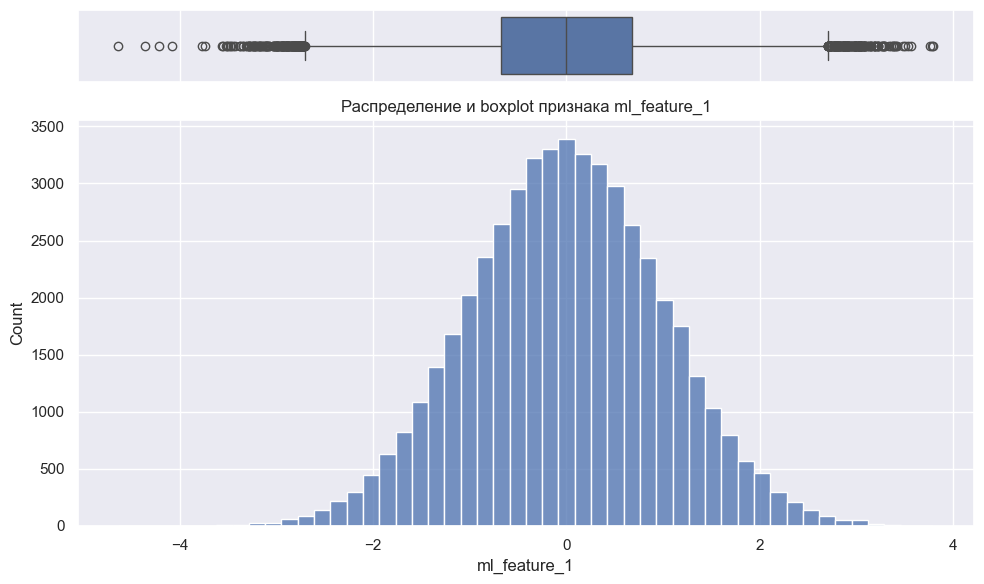

In [25]:
plot_outliers(df, 'ml_feature_1')

распределение похоже на нормальное. выбросы есть, распределены симметрично, но слева есть пара выбиващихся от основной массы выбросов. 

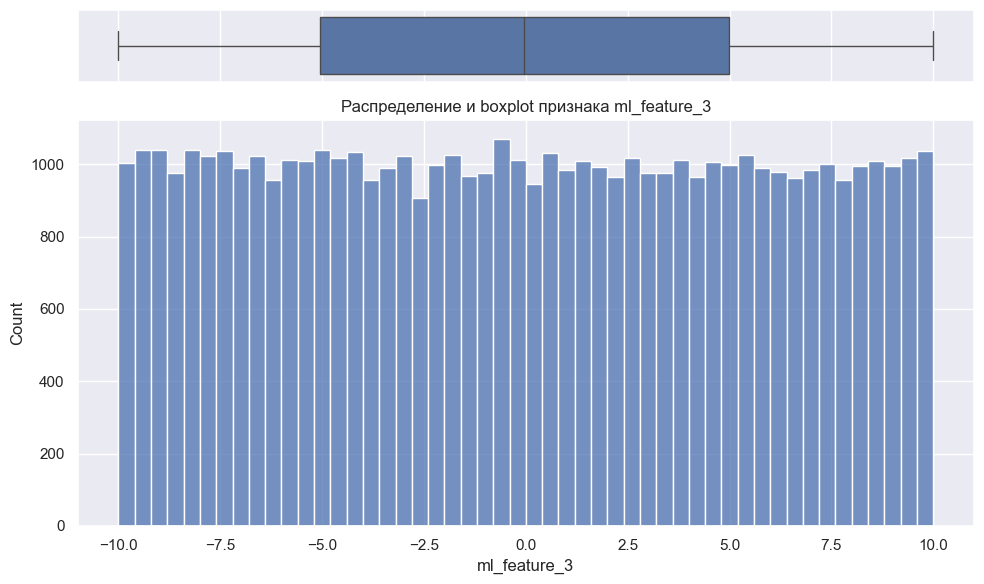

In [26]:
plot_outliers(df, 'ml_feature_3')

распределение равномерное на отрезке от -10 до 10. видимо, фича уже обработана. выбросов нет. 

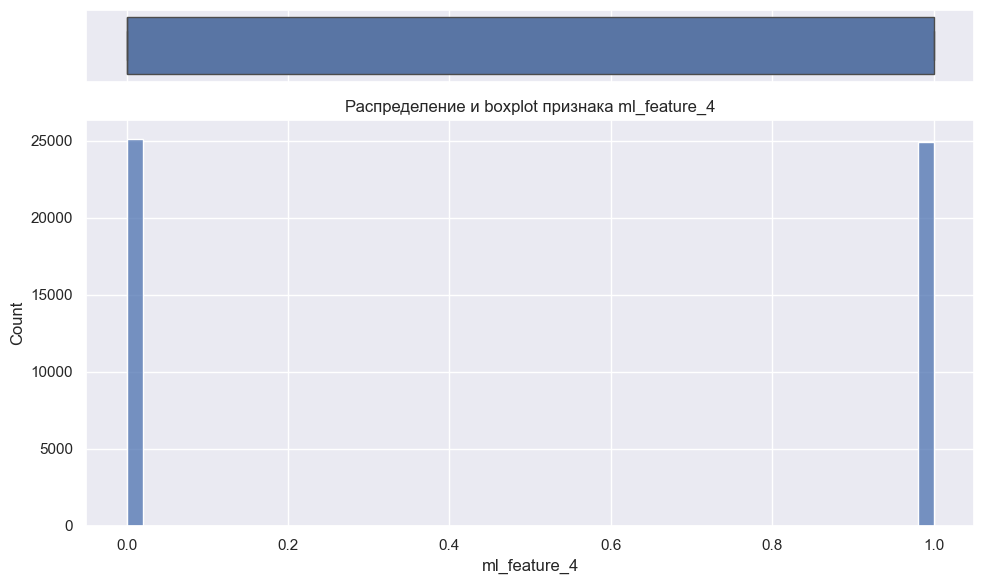

In [27]:
plot_outliers(df, 'ml_feature_4')

бинарная фича. выбросов нет

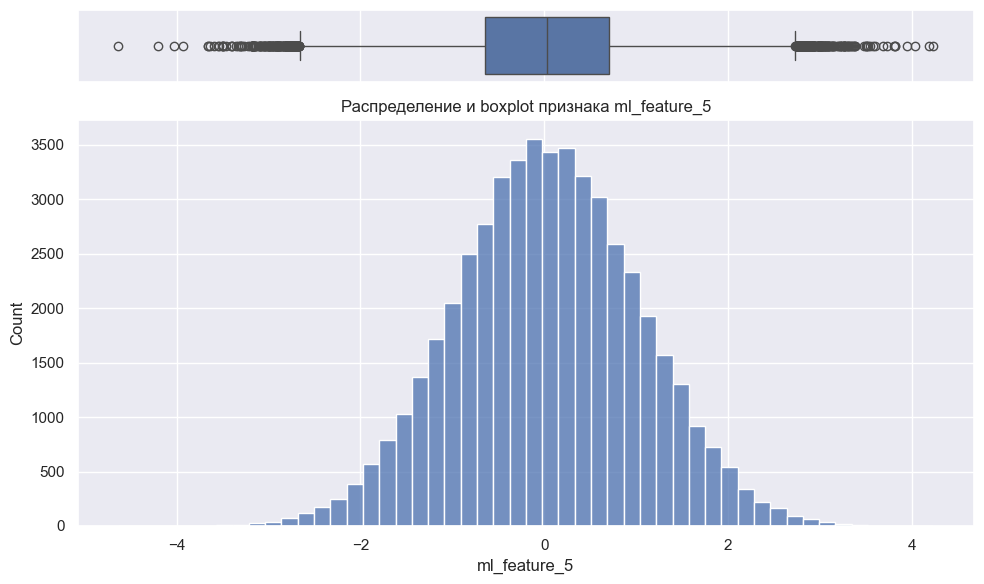

In [28]:
plot_outliers(df, 'ml_feature_5')

распределение похоже на нормальное. выбросы есть, распределены симметрично, но слева есть пара выбиващихся от основной массы выбросов. 

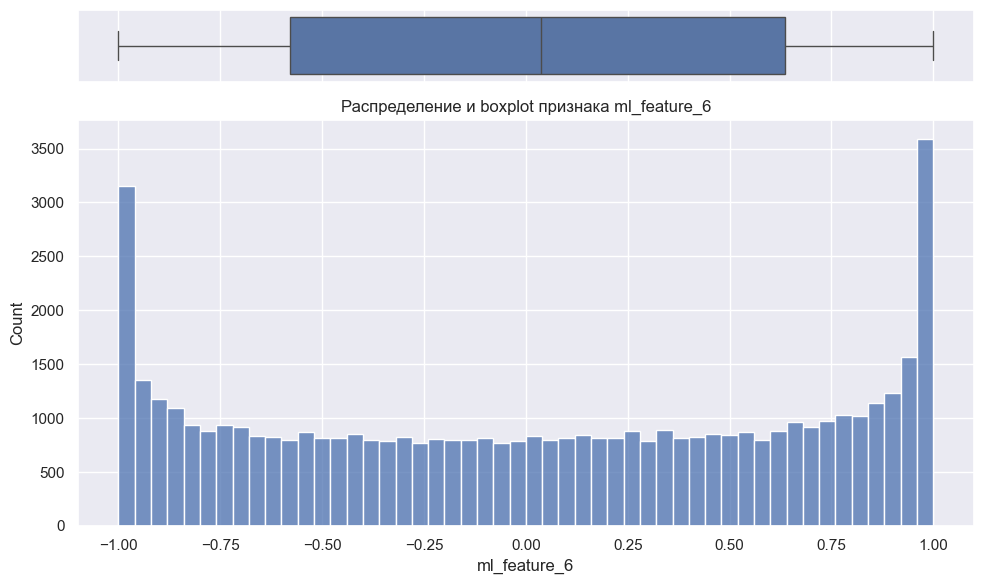

In [29]:
plot_outliers(df, 'ml_feature_6')

выбросов нет. 

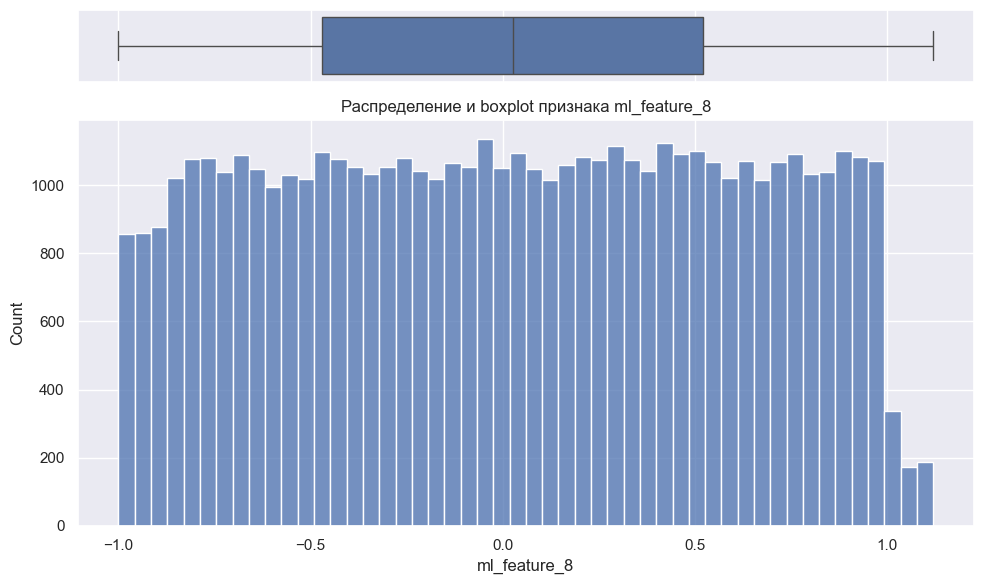

In [30]:
plot_outliers(df, 'ml_feature_8')

выбросов нет

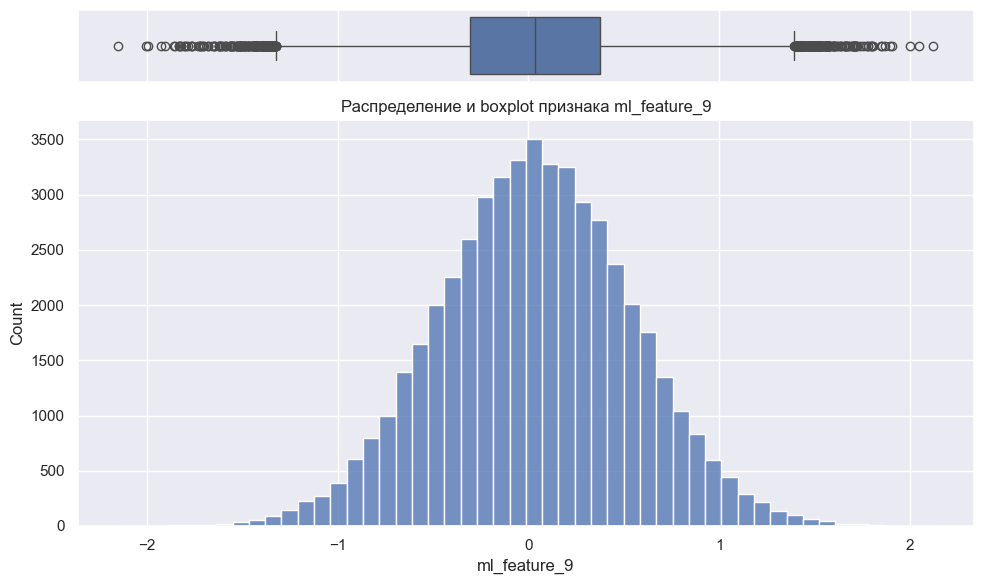

In [31]:
plot_outliers(df, 'ml_feature_9')

выбросов нет

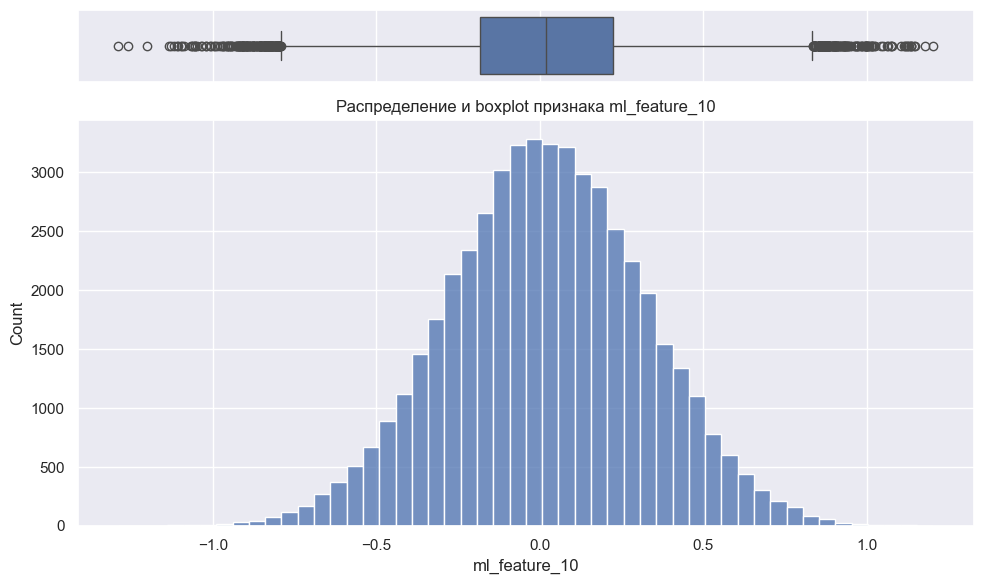

In [32]:
plot_outliers(df, 'ml_feature_10')

выбросов нет 

### Корреляция с таргетом и мультиколлинеарность 

**Корреляция с таргетом**

In [33]:
phik_corr = df.phik_matrix(interval_cols=num_cols)

phik_with_click = (
    phik_corr["click"]
    .drop("click")              
    .sort_values(ascending=False))

phik_with_click

C14                 0.320374
C17                 0.320232
site_domain         0.303749
C18                 0.257836
C21                 0.251792
C19                 0.208802
device_model        0.196182
ml_feature_9        0.187801
ml_feature_10       0.169983
C15                 0.165941
app_category        0.156537
site_category       0.155008
ml_feature_8        0.153598
app_domain          0.152415
C20                 0.152383
C16                 0.144262
device_conn_type    0.129954
ml_feature_6        0.091314
ml_feature_5        0.080014
device_type         0.071790
C1                  0.045930
day_of_week         0.023482
ml_feature_7        0.022622
banner_pos          0.022605
time_of_day         0.015566
ml_feature_1        0.010056
ml_feature_2        0.003790
ml_feature_4        0.000000
ml_feature_3        0.000000
Name: click, dtype: float64

C14, C17, site_domain оказались самыми коррелированными с таргетом признаками. значение phik для них 0.3 - 0.32. наименее коррелированные: ml_feature_3, ml_feature_4, ml_feature_2. 

для проверки мультиколлинеарности построим полную матрицу phik и дополнительно посчитаем кф-ты VIF

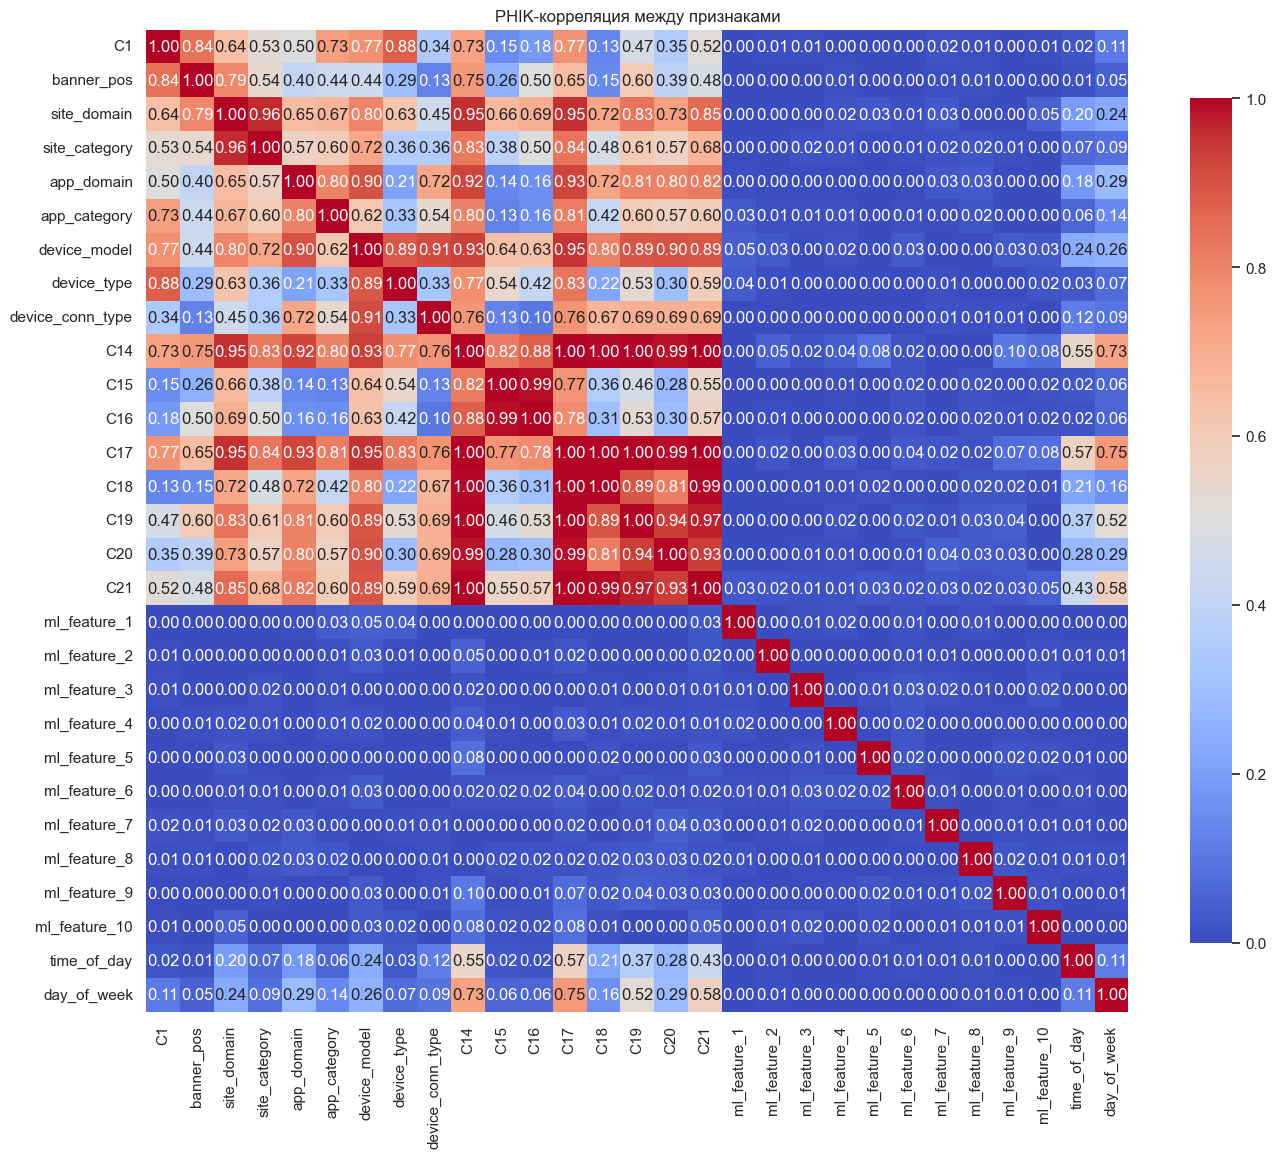

In [34]:
X = df.drop(columns=['click'])

phik_matrix = X.phik_matrix(interval_cols=num_cols)


plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_matrix,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    annot=True,     
    fmt=".2f",         
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("PHIK-корреляция между признаками")
plt.tight_layout()
plt.show()

- оставляем все ml_feature   
- time_of_day и day_of_week  
- удалим banner_pos из-за высокой корреляции с С1 (С1 характеризует весь контекст показа + сильнее коррелирован с таргетом). 
- удалим device_type из-за высокой корреляции с С1 (С1 характеризует весь контекст показа)  
- удалим site_category, C14, C17, device_model, C19, C21 из-за высокой корреляции с site_domain (site_domain сильнее коррелирован с таргетом)  
- удалим С16 из-за высокой корреляции с С15 
- удалим С20 из-за высокой корреляци с С18 
- удалим app_category из-за выосокой корреляции с app_domain

In [35]:
# выпишем колонки, которые нужно удалить из-за высокой корреляции с другими признаками
columns_to_del = ['banner_pos', 'device_type', 'site_category', 'C14', 'C17', 
                  'device_model',  'C19', 'C21', 'C16', 'C20', 'app_category']
df = df.drop(columns=columns_to_del)

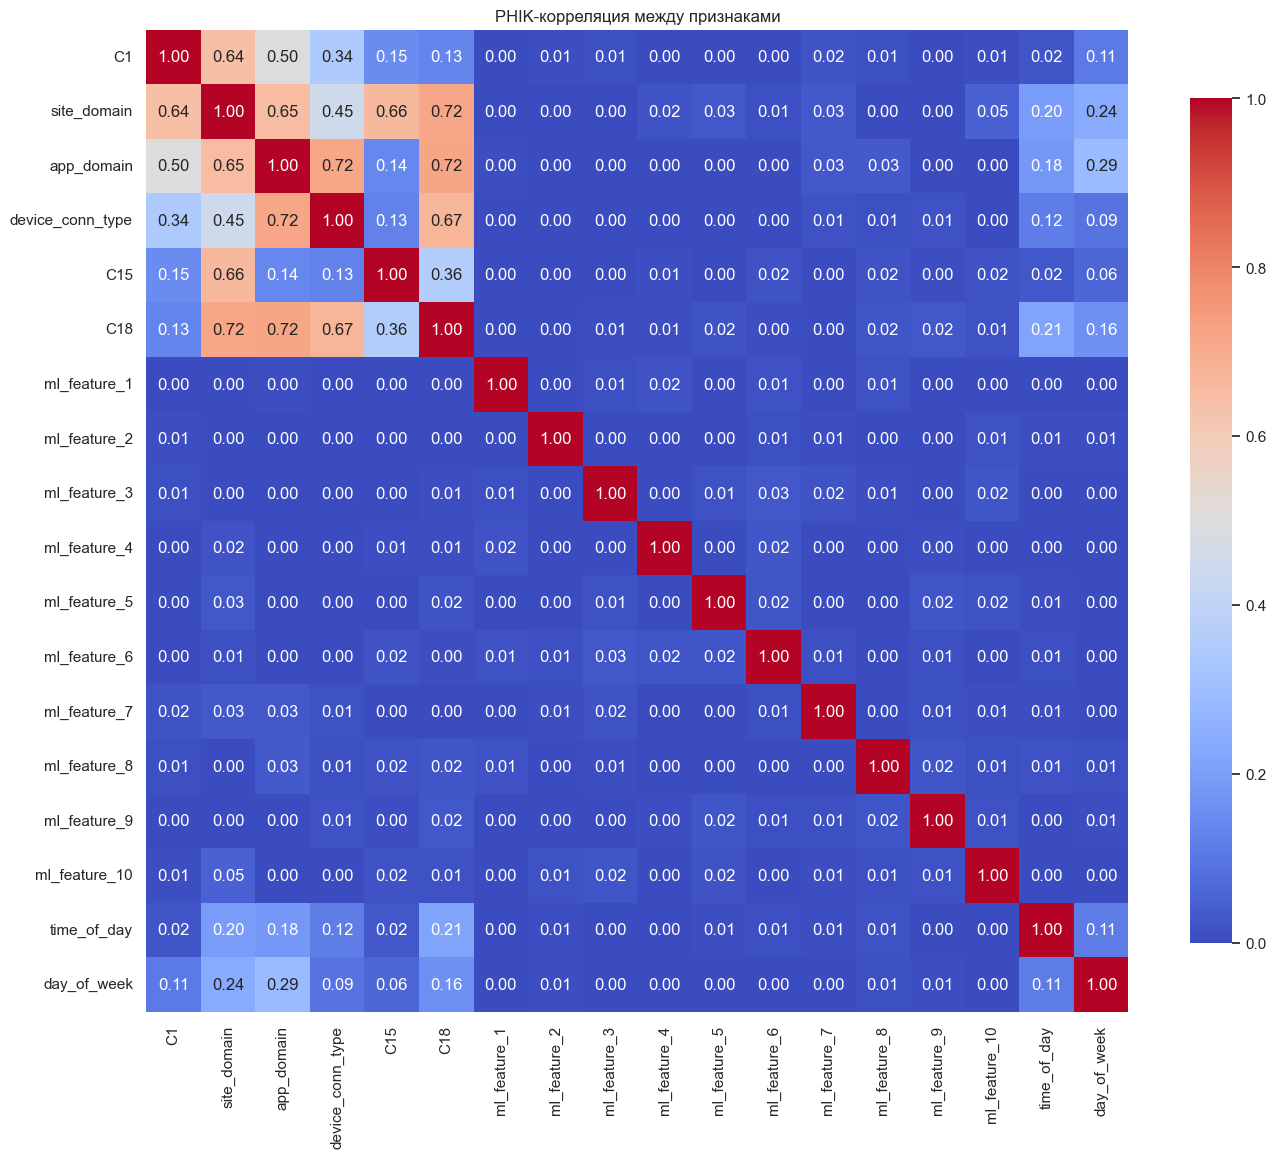

In [36]:
X = df.drop(columns=['click'])

phik_matrix = X.phik_matrix(interval_cols=num_cols)


plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_matrix,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    annot=True,     
    fmt=".2f",         
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("PHIK-корреляция между признаками")
plt.tight_layout()
plt.show()

In [37]:
X = df[num_cols].copy()
X['const'] = 1.0


vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df["VIF"] = [round(variance_inflation_factor(X.values, i), 2) for i in range(X.shape[1])]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
8,const,2.01
0,ml_feature_1,1.00
1,ml_feature_3,1.00
2,ml_feature_4,1.00
3,ml_feature_5,1.00
4,ml_feature_6,1.00
5,ml_feature_8,1.00
6,ml_feature_9,1.00
7,ml_feature_10,1.00


линейная связь между численными фичами отсутствует (R2 нулевой почти для всех фичей)

### Итоги EDA  
- таргет имеет неравномерное распределение: кликов куда меньше, чем игнорирований рекламы    
- пропусков в данных не обнаружено   
- разработана стратегия для кодирования категоральных признаков   
- численные фичи не требуеют предобратоки   
- удалены коррелированные фичи  

## 3. Разделение данных на выборки

In [38]:
X = df.drop(columns=['click'])
y = df['click']

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_tmp, y_tmp,
    test_size=0.25,    
    stratify=y_tmp,
    random_state=RANDOM_STATE
)

X_train.shape, X_test.shape, X_calib.shape

((30000, 18), (10000, 18), (10000, 18))

In [39]:
y_train.sum()/len(y_train), y_test.sum()/len(y_test)

(np.float64(0.17206666666666667), np.float64(0.1721))

разделили данные на трейн и тест. сохранили распределение таргета 

## 4. Предобработка данных — построение пайплайнов

### Создание пайпланов для предобработки данных

In [40]:
cat_cols = [i for i in df.columns if i not in num_cols + ['click']]
cat_cols

['C1',
 'site_domain',
 'app_domain',
 'device_conn_type',
 'C15',
 'C18',
 'ml_feature_2',
 'ml_feature_7',
 'time_of_day',
 'day_of_week']

вспомним стратегию кодирования категоральных признаков: 
- для категорий 'C1',  'app_domain', 'device_conn_type', 'C15', 'C18', 'ml_feature_2', 'ml_feature_7', 'time_of_day', 'day_of_week' используем OHE   
  
- для 'site_domain' используем TE 

In [41]:
cat_OHE = [i for i in cat_cols if i != 'site_domain']

cat_TE = 'site_domain'

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        # категоральные OHE 
        ('cat_OHE', 
         Pipeline(steps=[
             ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
         ]),
         cat_OHE),
        # категориальные TE
        ('cat_TE', 
         Pipeline(steps=[
             ('TE',  ce.TargetEncoder(cols=cat_TE, smoothing=10))
         ]),
         [cat_TE]),


        # числовые признаки
        ('num', 
         Pipeline(steps=[
             ('scaler', StandardScaler())
         ]),
         num_cols)
    ],
    remainder='drop'
)

## 5. Отбор признаков

### Фильтрационные методы 

In [43]:
df[num_cols].describe() 

,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


In [44]:
X_scaled = StandardScaler().fit_transform(df[num_cols])

# VarianceThreshold по доле дисперсии
vt = VarianceThreshold(threshold=0.1)
vt.fit(X_scaled)

# признаки с низкой вариацией
low_variance_cols = [
    col for col, keep in zip(num_cols, vt.get_support()) if not keep
]

print("Признаки с низкой вариацией (variance < 0.1 после стандартизации):")
print(low_variance_cols)

Признаки с низкой вариацией (variance < 0.1 после стандартизации):
[]


таких признаков нет. 

### Методы обертки

In [45]:
# используем прямую обертку для отбора признаков

estimator = LogisticRegression(
    solver="liblinear",   
    max_iter=1000,
    class_weight="balanced"  
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sfs = SequentialFeatureSelector(estimator, n_features_to_select="auto", direction='forward',
                                 cv=cv, scoring='average_precision', tol=1e-4, n_jobs = -1)

# применять модель нужно к предобработанным данным
X_preprocessed = preprocessor.fit_transform(X_train, y_train)
sfs.fit(X_preprocessed, y_train)

# Получаем отобранные признаки
selected_features = sfs.get_support() 

In [46]:
feature_names = preprocessor.get_feature_names_out()

# выбранные
df_selected = pd.DataFrame({
    "feature": feature_names[selected_features],
    "selected": True
})

# невыбранные
df_dropped = pd.DataFrame({
    "feature": feature_names[~selected_features],
    "selected": False
})

display(df_selected)
display(df_dropped)

,feature,selected
0,cat_OHE__C1_1002,True
1,cat_OHE__C1_1005,True
2,cat_OHE__app_domain_0e8616ad,True
3,cat_OHE__app_domain_33da2e74,True
4,cat_OHE__app_domain_5c5a694b,True
5,cat_OHE__app_domain_5c620f04,True
6,cat_OHE__app_domain_82e27996,True
7,cat_OHE__app_domain_ae637522,True
8,cat_OHE__app_domain_b8d325c3,True
9,cat_OHE__app_domain_df32afa9,True


,feature,selected
0,cat_OHE__C1_1001,False
1,cat_OHE__C1_1007,False
2,cat_OHE__C1_1008,False
3,cat_OHE__C1_1010,False
4,cat_OHE__C1_1012,False
5,cat_OHE__app_domain_0654b444,False
6,cat_OHE__app_domain_2347f47a,False
7,cat_OHE__app_domain_45a51db4,False
8,cat_OHE__app_domain_5b9c592b,False
9,cat_OHE__app_domain_6f7ca2ba,False


поля device_conn_type, ml_feature_1, ml_feature_2, num__ml_feature_3, num__ml_feature_4, day_of_week оказались ненужными после применения прямой обертки. удалим их. 

оставим только нужные признаки. придется заново использовать train_test_plit

In [47]:
df = df.drop(columns=[
    'device_conn_type',
    'ml_feature_1',
    'ml_feature_2',
    'ml_feature_3',
    'ml_feature_4',
    'day_of_week',
])

X = df.drop(columns=['click'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y)

X_train.shape, X_test.shape

((40000, 12), (10000, 12))

In [48]:
y_train.sum()/len(y_train), y_test.sum()/len(y_test)

(np.float64(0.17205), np.float64(0.1721))

In [49]:
df.columns 

Index(['click', 'C1', 'site_domain', 'app_domain', 'C15', 'C18',
       'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8',
       'ml_feature_9', 'ml_feature_10', 'time_of_day'],
      dtype='object')

In [50]:
# подправим список колонок для предроцессора 

cat_OHE = ['C1', 'app_domain', 'C15', 'C18', 'ml_feature_7', 'time_of_day']

cat_TE = 'site_domain'

num_cols = ['ml_feature_5', 'ml_feature_6', 'ml_feature_8',
            'ml_feature_9', 'ml_feature_10']

In [51]:
# обновим поля 

preprocessor = ColumnTransformer(
    transformers=[
        # категоральные OHE 
        ('cat_OHE', 
         Pipeline(steps=[
             ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
         ]),
         cat_OHE),
        # категориальные TE
        ('cat_TE', 
         Pipeline(steps=[
             ('TE',  ce.TargetEncoder(cols=cat_TE, smoothing=10))
         ]),
         [cat_TE]),


        # числовые признаки
        ('num', 
         Pipeline(steps=[
             ('scaler', StandardScaler())
         ]),
         num_cols)
    ],
    remainder='drop'
)

## 6. Обучение базовой модели

### Бейзлайн 

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [53]:
scoring_dummy = {
    "pr_auc": "average_precision"
}

In [54]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

dummy_cv = cross_validate(
    dummy, X_train, y_train,
    cv=cv, scoring=scoring_dummy, n_jobs=-1
)


### Логистическая регрессия 

In [55]:
scoring = {
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [56]:
pipe_lr = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        solver="liblinear",
        max_iter=10000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

lr_cv = cross_validate(
    pipe_lr, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

### SVC 

In [57]:
pipe_svc = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", SVC(
        kernel="linear",
        probability=False,          
        class_weight="balanced"
    ))
])

svc_cv = cross_validate(
    pipe_svc, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

### Сравнение моделей 

In [58]:
def summarize_cv(cv_dict, model_name: str) -> dict:
    return {
        "model": model_name,
        "PR-AUC (mean)": np.mean(cv_dict["test_pr_auc"]),
        "PR-AUC (std)":  np.std(cv_dict["test_pr_auc"]),
        "Precision (mean)": np.mean(cv_dict["test_precision"]),
        "Recall (mean)": np.mean(cv_dict["test_recall"]),
        "F1 (mean)": np.mean(cv_dict["test_f1"]),
    }

results = pd.DataFrame([
    summarize_cv(lr_cv, "LogisticRegression"),
    summarize_cv(svc_cv, "Linear SVC"),
]).sort_values("PR-AUC (mean)", ascending=False)


results_rounded = results.copy()
for col in results.columns:
    if col != "model":
        results_rounded[col] = results_rounded[col].astype(float).round(4)


pr_auc_scores = dummy_cv["test_pr_auc"]

print('Результат базовой модели')
print(f'Mean PR-AUC: {pr_auc_scores.mean():.4f}')
print()
print('Результаты логрегрессии и SVC с предобработкой признаков')
display(results_rounded)

Результат базовой модели
Mean PR-AUC: 0.1720

Результаты логрегрессии и SVC с предобработкой признаков


,model,PR-AUC (mean),PR-AUC (std),Precision (mean),Recall (mean),F1 (mean)
0,LogisticRegression,0.3998,0.0101,0.3043,0.6815,0.4207
1,Linear SVC,0.3981,0.0098,0.3033,0.6858,0.4206


результат логрега и svc более чем в 2 раза превышает результат базовой модели по pr-auc. стандартное оклонение низкое - нет переобучения

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

### Определим сетки гиперпараметров 

In [59]:
param_grid_lr = {
    "clf__solver": ["liblinear"],
    "clf__penalty": ["l2"],
    "clf__C": [0.1, 1, 100],
    "clf__class_weight": [None, "balanced"],
    "clf__max_iter": [5000],
}

param_grid_svc = {
    "clf__kernel": ["linear"],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": ["balanced"],
}

### Grid Search 

In [60]:
# грид для логрегрессии

grid_search_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

In [61]:
# грид для svc

grid_search_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

In [62]:
grid_search_lr.fit(X_train, y_train);

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [63]:
grid_search_svc.fit(X_train, y_train);

Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [64]:
def top_n_from_gridsearch(gs, n=10):
    """
    Возвращает DataFrame с top-n конфигурациями GridSearchCV
    """
    results = pd.DataFrame(gs.cv_results_)

    cols = [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "params"
    ]

    top_n = (
        results[cols]
        .sort_values("rank_test_score")
        .head(n)
        .reset_index(drop=True)
    )

    return top_n

In [65]:
top10_lr = top_n_from_gridsearch(grid_search_lr, n=10)

top10_lr = top10_lr.rename(columns={
    "mean_test_score": "PR-AUC (mean)",
    "std_test_score": "PR-AUC (std)",
    "rank_test_score": "rank"
})

In [66]:
top10_svc = top_n_from_gridsearch(grid_search_svc, n=10)

top10_svc = top10_svc.rename(columns={
    "mean_test_score": "PR-AUC (mean)",
    "std_test_score": "PR-AUC (std)",
    "rank_test_score": "rank"
})

In [67]:
for df in [top10_lr, top10_svc]:
    df["PR-AUC (mean)"] = df["PR-AUC (mean)"].round(4)
    df["PR-AUC (std)"] = df["PR-AUC (std)"].round(4)

pd.set_option('display.max_colwidth', None)

display(top10_svc)
display(top10_lr)

,rank,PR-AUC (mean),PR-AUC (std),params
0,1,0.4001,0.0097,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}"
1,2,0.3981,0.0098,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}"
2,3,0.3977,0.0101,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}"


,rank,PR-AUC (mean),PR-AUC (std),params
0,1,0.4020,0.0100,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
1,2,0.4019,0.0103,"{'clf__C': 0.1, 'clf__class_weight': None, 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
2,3,0.4013,0.0102,"{'clf__C': 1, 'clf__class_weight': None, 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
3,4,0.4004,0.0103,"{'clf__C': 100, 'clf__class_weight': None, 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
4,5,0.3998,0.0101,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
5,6,0.3990,0.0104,"{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"


In [68]:
print("Лучшие параметры LogisticRegression:")
print(grid_search_lr.best_params_)

Лучшие параметры LogisticRegression:
{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}


In [69]:
print("Лучшие параметры Linear SVC:")
print(grid_search_svc.best_params_)

Лучшие параметры Linear SVC:
{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}


теперь сделам сетку локальной вокруг лучших параметров 

In [70]:
param_grid_lr = {
    "clf__solver": ["liblinear"],
    "clf__penalty": ["l2"],
    "clf__C": [0.03, 0.07, 0.2, 1],
    "clf__class_weight": [None, "balanced"],
    "clf__max_iter": [10000],
}

param_grid_svc = {
    "clf__kernel": ["linear"],
    "clf__C": [0.05, 0.1, 0.5, 1],
    "clf__class_weight": ["balanced"],
}

In [71]:
grid_search_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

In [72]:
# грид для svc

grid_search_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

In [73]:
grid_search_lr.fit(X_train, y_train);

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [74]:
grid_search_svc.fit(X_train, y_train);

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [75]:
top10_svc = top_n_from_gridsearch(grid_search_svc, n=10)

top10_svc = top10_svc.rename(columns={
    "mean_test_score": "PR-AUC (mean)",
    "std_test_score": "PR-AUC (std)",
    "rank_test_score": "rank"
})
top10_lr = top_n_from_gridsearch(grid_search_lr, n=10)

top10_lr = top10_lr.rename(columns={
    "mean_test_score": "PR-AUC (mean)",
    "std_test_score": "PR-AUC (std)",
    "rank_test_score": "rank"
})

for df in [top10_lr, top10_svc]:
    df["PR-AUC (mean)"] = df["PR-AUC (mean)"].round(4)
    df["PR-AUC (std)"] = df["PR-AUC (std)"].round(4)

pd.set_option('display.max_colwidth', None)

display(top10_svc)
display(top10_lr)

,rank,PR-AUC (mean),PR-AUC (std),params
0,1,0.4005,0.0100,"{'clf__C': 0.05, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}"
1,2,0.4001,0.0097,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}"
2,3,0.3985,0.0097,"{'clf__C': 0.5, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}"
3,4,0.3981,0.0098,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}"


,rank,PR-AUC (mean),PR-AUC (std),params
0,1,0.4024,0.0103,"{'clf__C': 0.2, 'clf__class_weight': None, 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
1,2,0.4019,0.0101,"{'clf__C': 0.07, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
2,3,0.4014,0.0101,"{'clf__C': 0.2, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
3,4,0.4013,0.0102,"{'clf__C': 1, 'clf__class_weight': None, 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
4,5,0.4008,0.0103,"{'clf__C': 0.07, 'clf__class_weight': None, 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
5,6,0.3998,0.0101,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
6,7,0.3995,0.0101,"{'clf__C': 0.03, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
7,8,0.3947,0.0104,"{'clf__C': 0.03, 'clf__class_weight': None, 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"


## 8. Финальная модель

### Обучение финальной модели 

In [76]:
best_logreg_pipe = grid_search_lr.best_estimator_
best_svc_pipe = grid_search_svc.best_estimator_

### Метрики на тестовой выборке 

In [77]:
y_test_proba_lr = best_logreg_pipe.predict_proba(X_test)[:, 1]

pr_auc_lr = average_precision_score(y_test, y_test_proba_lr)
brier_lr = brier_score_loss(y_test, y_test_proba_lr)

print("LogisticRegression (test):")
print(f"PR-AUC = {pr_auc_lr:.4f}")
print(f"Brier = {brier_lr:.4f}")


LogisticRegression (test):
PR-AUC = 0.3928
Brier = 0.1255


In [78]:
y_test_scores_svc = best_svc_pipe.decision_function(X_test)

pr_auc_svc = average_precision_score(y_test, y_test_scores_svc)

print("\nLinear SVC (test):")
print(f"PR-AUC  = {pr_auc_svc:.4f}")


Linear SVC (test):
PR-AUC  = 0.3913


на тесте модели показали близкий к валидационном результат (0.39 у обеих моделей). лог рег оказался хорошо откалиброван (Brier 0.126)

### Анализ весов модели 

выведем веса логрега, тк они имеют понятную интерпретацию

In [79]:
logreg = best_logreg_pipe.named_steps["clf"]
feature_names = best_logreg_pipe.named_steps["prep"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": logreg.coef_.ravel()
})


coef_df["abs_weight"] = coef_df["weight"].abs()

coef_df = coef_df.sort_values(by="abs_weight", ascending=False).reset_index(drop=True)

display(coef_df)

,feature,weight,abs_weight
0,cat_TE__site_domain,5.181091,5.181091
1,cat_OHE__C18_1,-1.171985,1.171985
2,cat_OHE__app_domain_82e27996,-0.773778,0.773778
3,cat_OHE__app_domain_ae637522,-0.755202,0.755202
4,cat_OHE__app_domain_df32afa9,-0.750418,0.750418
5,cat_OHE__app_domain_b8d325c3,0.637591,0.637591
6,cat_OHE__app_domain_5c620f04,-0.602959,0.602959
7,cat_OHE__app_domain_b9528b13,0.598012,0.598012
8,cat_OHE__ml_feature_7_Z,-0.585766,0.585766
9,cat_OHE__app_domain_0e8616ad,-0.556704,0.556704


самыми значимыми оказались поля cat_TE__site_domain (5.18) и cat_OHE__C18_1 (1.17)

## 9. Калибровка модели

### Текущая колибровка 

In [80]:
# преобразуем выходы svc в вероятности с помощью сигмоиды 

y_test_scores_svc_sigm = 1 / (1 + np.exp(-y_test_scores_svc))

<Figure size 600x600 with 0 Axes>

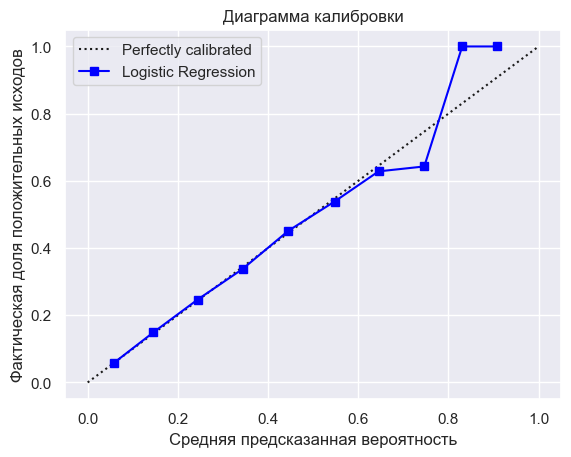

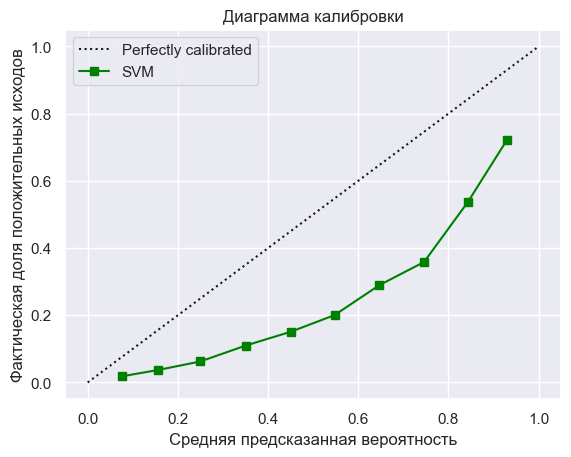

In [81]:
prob_true_lr, prob_pred_lr = calibration_curve(
y_test,                               
y_test_proba_lr,  
n_bins=10                            
)

prob_true_svm, prob_pred_svm = calibration_curve(y_test, y_test_scores_svc_sigm, n_bins=10)

plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true_lr, prob_pred_lr, y_test).plot(label='Logistic Regression', color='blue')
plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

CalibrationDisplay(prob_true_svm, prob_pred_svm, y_test).plot(label='SVM', color='green')
plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

ожидаемо логрег хорошо откалиброван. svc систематически занижает вероятность

### Применение методов калибровки 

In [82]:
calibrated_logreg = CalibratedClassifierCV(
    estimator=best_logreg_pipe,
    method="isotonic",
    cv='prefit'   # калибруем уже обученную модель на X_calib
)
calibrated_logreg.fit(X_calib, y_calib);

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [83]:
calibrated_svc = CalibratedClassifierCV(
    estimator=best_svc_pipe,
    method="isotonic",
    cv="prefit"
)
calibrated_svc.fit(X_calib, y_calib);

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [84]:
# до калибровки
proba_lr_before = best_logreg_pipe.predict_proba(X_test)[:, 1]
scores_svc = 1 / (1 + np.exp(-best_svc_pipe.decision_function(X_test)))

# после калибровки
proba_lr_after = calibrated_logreg.predict_proba(X_test)[:, 1]
proba_svc_after = calibrated_svc.predict_proba(X_test)[:, 1]

### Сравнение метрик калибровки 

<Figure size 600x600 with 0 Axes>

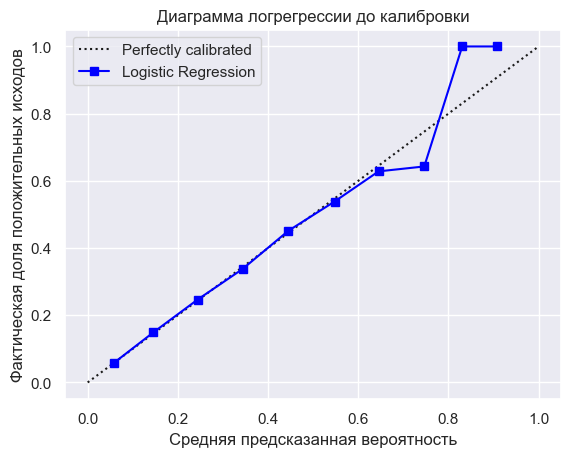

In [85]:
prob_true_lr, prob_pred_lr = calibration_curve(
y_test,                               
proba_lr_before,  
n_bins=10                            
)

plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true_lr, prob_pred_lr, y_test).plot(label='Logistic Regression', color='blue')
plt.title("Диаграмма логрегрессии до калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x600 with 0 Axes>

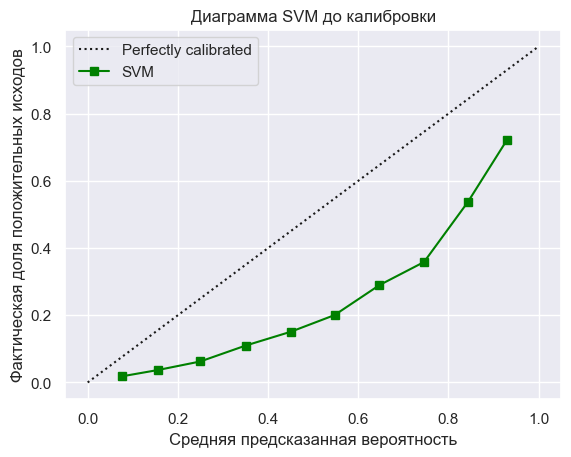

In [86]:
prob_true_svm, prob_pred_svm = calibration_curve(y_test, scores_svc, n_bins=10)

plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true_svm, prob_pred_svm, y_test).plot(label='SVM', color='green')
plt.title("Диаграмма SVM до калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x600 with 0 Axes>

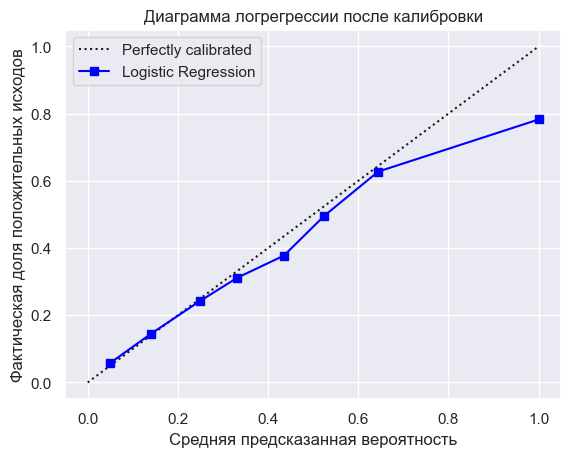

In [87]:
prob_true_lr, prob_pred_lr = calibration_curve(
y_test,                               
proba_lr_after,  
n_bins=10                            
)

plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true_lr, prob_pred_lr, y_test).plot(label='Logistic Regression', color='blue')
plt.title("Диаграмма логрегрессии после калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x600 with 0 Axes>

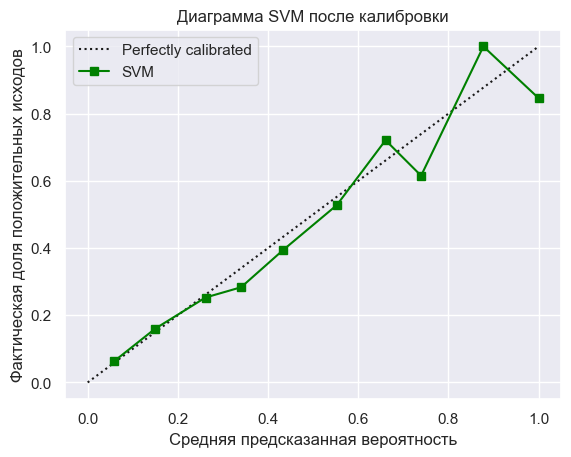

In [88]:
prob_true_svm, prob_pred_svm = calibration_curve(y_test, proba_svc_after, n_bins=10)

plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true_svm, prob_pred_svm, y_test).plot(label='SVM', color='green')
plt.title("Диаграмма SVM после калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.show()

In [89]:

def calibration_errors(y_true, y_prob, n_bins=10):
    """
    считает ECE и MCE
    """
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    mce = 0.0
    n = len(y_true)

    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            bin_confidence = y_prob[mask].mean()
            bin_accuracy = y_true[mask].mean()
            bin_error = abs(bin_accuracy - bin_confidence)

            ece += (mask.sum() / n) * bin_error
            mce = max(mce, bin_error)

    return ece, mce

In [90]:
results = pd.DataFrame([
    {
        "model": "LogReg (before)",
        "PR-AUC": average_precision_score(y_test, proba_lr_before),
        "Brier": brier_score_loss(y_test, proba_lr_before),
        "ECE": calibration_errors(y_test, proba_lr_before)[0],
        "MCE": calibration_errors(y_test, proba_lr_before)[1],
    },
    {
        "model": "LogReg (after isotonic)",
        "PR-AUC": average_precision_score(y_test, proba_lr_after),
        "Brier": brier_score_loss(y_test, proba_lr_after),
        "ECE": calibration_errors(y_test, proba_lr_after)[0],
        "MCE": calibration_errors(y_test, proba_lr_after)[1],
    },
    {
        "model": "SVC (raw sigmoid)",
        "PR-AUC": average_precision_score(y_test, scores_svc),
        "Brier": brier_score_loss(y_test, scores_svc),
        "ECE": calibration_errors(y_test, scores_svc)[0],
        "MCE": calibration_errors(y_test, scores_svc)[1],
    },
    {
        "model": "SVC (after isotonic)",
        "PR-AUC": average_precision_score(y_test, proba_svc_after),
        "Brier": brier_score_loss(y_test, proba_svc_after),
        "ECE": calibration_errors(y_test, proba_svc_after)[0],
        "MCE": calibration_errors(y_test, proba_svc_after)[1],
    },
])


results[["PR-AUC", "Brier", "ECE", "MCE"]] = (
    results[["PR-AUC", "Brier", "ECE", "MCE"]].round(4)
)

results

,model,PR-AUC,Brier,ECE,MCE
0,LogReg (before),0.3928,0.1255,0.0033,0.1694
1,LogReg (after isotonic),0.3755,0.1260,0.0095,0.0479
2,SVC (raw sigmoid),0.3913,0.2049,0.2671,0.3875
3,SVC (after isotonic),0.3739,0.1261,0.0111,0.1241


## 10. Оценка качества калибровки

In [91]:
results

,model,PR-AUC,Brier,ECE,MCE
0,LogReg (before),0.3928,0.1255,0.0033,0.1694
1,LogReg (after isotonic),0.3755,0.1260,0.0095,0.0479
2,SVC (raw sigmoid),0.3913,0.2049,0.2671,0.3875
3,SVC (after isotonic),0.3739,0.1261,0.0111,0.1241


калибровка практически не повлияла на ранжирующую способность моделей (PR-AUC изменился незначительно), что ожидаемо, тк калибровка не направлена на улучшение ранжирования. при этом для модели SVC изотоническая калибровка существенно улучшила качество вероятностных предсказаний: Brier score и ECE резко снизились по сравнению с вариантом с сигмоидой. для логистической регрессии эффект калибровки  привёл к ухудшению калибровочных метрик. у нее изначально хорошая калибровка. в итоге калибровка является целесообразной для SVC, но не даёт выигрыша для логистической регрессии.  
  
лучшая модель по всем метрикам - лог регрессия до калибровки

## 11. Финальный отчёт и выводы

### Сводные результаты

In [92]:
# результаты базовой модели

dummy_summary = pd.DataFrame([{
    "model": "DummyClassifier (most_frequent)",
    "PR-AUC": float(pr_auc_scores.mean())
}]).round(4)

print('DummyClassifier')
display(dummy_summary)

DummyClassifier


,model,PR-AUC
0,DummyClassifier (most_frequent),0.172


In [93]:
# лучшая модель - логрег до калибровки

best_clf = best_logreg_pipe.named_steps["clf"]
best_params = best_clf.get_params()

best_model_summary = pd.DataFrame([{
    "model": "Best model: LogisticRegression (before calibration)",
    "solver": best_params.get("solver"),
    "C": best_params.get("C"),
    "penalty": best_params.get("penalty"),
    "class_weight": str(best_params.get("class_weight")),
    "max_iter": best_params.get("max_iter"),
}])

print("\nBest model params")
display(best_model_summary)


Best model params


,model,solver,C,penalty,class_weight,max_iter
0,Best model: LogisticRegression (before calibration),liblinear,0.2,l2,None,10000


In [94]:
print("\n Metrics before / after calibration")
display(results.round(4).head(2))


 Metrics before / after calibration


,model,PR-AUC,Brier,ECE,MCE
0,LogReg (before),0.3928,0.1255,0.0033,0.1694
1,LogReg (after isotonic),0.3755,0.1260,0.0095,0.0479


In [95]:
feature_names = best_logreg_pipe.named_steps["prep"].get_feature_names_out()
coef = best_logreg_pipe.named_steps["clf"].coef_.ravel()

top5_features = (
    pd.DataFrame({"feature": feature_names, "weight": coef})
      .assign(abs_weight=lambda d: d["weight"].abs())
      .sort_values("abs_weight", ascending=False)
      .head(5)
      .drop(columns=["abs_weight"])
      .reset_index(drop=True)
)

print("\nTop-5 important features (LogReg)")
display(top5_features)


Top-5 important features (LogReg)


,feature,weight
0,cat_TE__site_domain,5.181091
1,cat_OHE__C18_1,-1.171985
2,cat_OHE__app_domain_82e27996,-0.773778
3,cat_OHE__app_domain_ae637522,-0.755202
4,cat_OHE__app_domain_df32afa9,-0.750418


### Выводы

по сравнению с базовой моделью DummyClassifier качество существенно улучшилось: PR-AUC вырос примерно с 0.17 до ~0.40. с точки зрения калибровки, исходная логистическая регрессия уже была достаточно хорошо откалибрована (низкие ECE и Brier), а изотоническая калибровка слегка ухудшила все показатели. для SVC калибровка существенно улучшила Brier и ECE, но итоговое качество по PR-AUC осталось ниже логистической регрессии. логистическая регрессия без дополнительной калибровки является наилучшей моделью в задаче и может рассматриваться как готовая к использованию в продакшене. 

### Рекомендации 

попробовать более сложные модели (катбуст, например)

## 12. Сохранение модели для продакшена

### Сохранение модели 

In [97]:
joblib.dump(best_logreg_pipe, 'churn_logreg_pipeline.joblib')

['churn_logreg_pipeline.joblib']

### Получение модели

In [98]:
loaded_model = joblib.load('churn_logreg_pipeline.joblib')
loaded_model

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_OHE', ...), ('cat_TE', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [99]:
X_check = X_test.copy()

In [100]:
proba_before = best_logreg_pipe.predict_proba(X_check)[:, 1]

In [101]:
proba_after = loaded_model.predict_proba(X_check)[:, 1]

In [102]:
print("Max abs diff:", np.max(np.abs(proba_before - proba_after)))

Max abs diff: 0.0
